In [56]:
from __future__ import absolute_import, division, print_function, unicode_literals

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

from IPython.display import clear_output
from six.moves import urllib

import tensorflow.compat.v2.feature_column as fc
import tensorflow as tf
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

# Importing , Splicing, and Scaling the dataset

In [67]:
df_retail = pd.read_excel("/home/whitelister/PycharmProjects/Learning AI/ML/Datasets/online+retail/Online Retail.xlsx")
df_retail.columns = [c.upper() for c in df_retail.columns]
# Encoding
df_retail = df_retail.drop(columns=["INVOICENO", "STOCKCODE"])
df_retail["INVOICEDATE"] = pd.to_datetime(df_retail["INVOICEDATE"])
df_retail["YEAR"] = df_retail["INVOICEDATE"].dt.year
df_retail["MONTH"] = df_retail["INVOICEDATE"].dt.month
df_retail["DAY"] = df_retail["INVOICEDATE"].dt.day
df_retail["HOUR"] = df_retail["INVOICEDATE"].dt.hour
df_retail["WEEKDAY"] = df_retail["INVOICEDATE"].dt.weekday
df_retail = df_retail.drop(columns=["INVOICEDATE"])
df_retail = df_retail.dropna()
df_retail["CUSTOMERID"] = df_retail["CUSTOMERID"].astype(int)
df_retail = df_retail.drop(columns=["DESCRIPTION"])
df_retail = pd.get_dummies(
    df_retail,
    columns=["COUNTRY"],
    dtype=int
)
# Splicing
df = df_retail.sample(frac=1, random_state=42).reset_index(drop=True)

train = df.iloc[:int(0.6 * len(df))]
valid = df.iloc[int(0.6 * len(df)):int(0.8 * len(df))]
test = df.iloc[int(0.8 * len(df)):]

In [68]:
df_retail[df_retail["UNITPRICE"] <= 0]
df_retail[df_retail["UNITPRICE"] > 1000]

,QUANTITY,UNITPRICE,CUSTOMERID,YEAR,MONTH,DAY,HOUR,WEEKDAY,COUNTRY_Australia,COUNTRY_Austria,...,COUNTRY_RSA,COUNTRY_Saudi Arabia,COUNTRY_Singapore,COUNTRY_Spain,COUNTRY_Sweden,COUNTRY_Switzerland,COUNTRY_USA,COUNTRY_United Arab Emirates,COUNTRY_United Kingdom,COUNTRY_Unspecified
45622,-1,1126.00,12503,2011,1,6,11,3,0,0,...,0,0,0,1,0,0,0,0,0,0
73446,-1,1715.85,12539,2011,1,27,12,3,0,0,...,0,0,0,1,0,0,0,0,0,0
117052,-1,1687.17,14911,2011,3,11,10,4,0,0,...,0,0,0,0,0,0,0,0,0,0
117053,-1,1687.17,14911,2011,3,11,10,4,0,0,...,0,0,0,0,0,0,0,0,0,0
117054,1,1687.17,14911,2011,3,11,10,4,0,0,...,0,0,0,0,0,0,0,0,0,0
117055,1,1687.17,14911,2011,3,11,10,4,0,0,...,0,0,0,0,0,0,0,0,0,0
144826,1,2382.92,12744,2011,4,4,13,0,0,0,...,0,0,1,0,0,0,0,0,0,0
144828,1,1252.95,12744,2011,4,4,13,0,0,0,...,0,0,1,0,0,0,0,0,0,0
144829,1,2053.07,12744,2011,4,4,13,0,0,0,...,0,0,1,0,0,0,0,0,0,0
144831,-1,2382.92,12744,2011,4,4,13,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [58]:
def check_scaled(name, X):
    print(f"\n{name}")
    print(f"Shape: {X.shape}")
    print(f"Mean: {X.mean():.6f}")
    print(f"Std : {X.std():.6f}")
    print(f"Min : {X.min():.6f}")
    print(f"Max : {X.max():.6f}")

check_scaled("Training", x_train)
check_scaled("Validation", x_valid)
check_scaled("Test", x_test)


Training
Shape: (244097, 44)
Mean: 0.000000
Std : 1.000000
Min : -296.933562
Max : 271.995064

Validation
Shape: (81366, 44)
Mean: 0.000161
Std : 0.987434
Min : -5.596360
Max : 296.847432

Test
Shape: (81366, 44)
Mean: -0.000369
Std : 0.986797
Min : -3.770553
Max : 174.674340


In [59]:
def scale_dataset(dataframe, scaler=None, fit_scaler=False):
    # Separate features and labels
    y = dataframe["UNITPRICE"].values
    X = dataframe.drop(columns=["UNITPRICE"]).values

    if fit_scaler:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
    else:
        X = scaler.transform(X)

    data = np.hstack((X, y.reshape(-1, 1)))

    return data, X, y, scaler

In [60]:
train, x_train, y_train, scaler = scale_dataset(
    train,
    fit_scaler=True
)

valid, x_valid, y_valid, _ = scale_dataset(
    valid,
    scaler=scaler
)

test, x_test, y_test, _ = scale_dataset(
    test,
    scaler=scaler
)

In [61]:
def check_scaled(name, X):
    print(f"\n{name}")
    print(f"Shape: {X.shape}")
    print(f"Mean: {X.mean():.6f}")
    print(f"Std : {X.std():.6f}")
    print(f"Min : {X.min():.6f}")
    print(f"Max : {X.max():.6f}")

check_scaled("Training", x_train)
check_scaled("Validation", x_valid)
check_scaled("Test", x_test)


Training
Shape: (244097, 44)
Mean: 0.000000
Std : 1.000000
Min : -296.933562
Max : 271.995064

Validation
Shape: (81366, 44)
Mean: 0.000161
Std : 0.987434
Min : -5.596360
Max : 296.847432

Test
Shape: (81366, 44)
Mean: -0.000369
Std : 0.986797
Min : -3.770553
Max : 174.674340


# MODEL

In [62]:
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train
lr_model.fit(x_train, y_train)

# Predict
y_pred = lr_model.predict(x_test)

In [63]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 2.8548
MSE  : 825.4203
RMSE : 28.7301
R²   : -0.0053


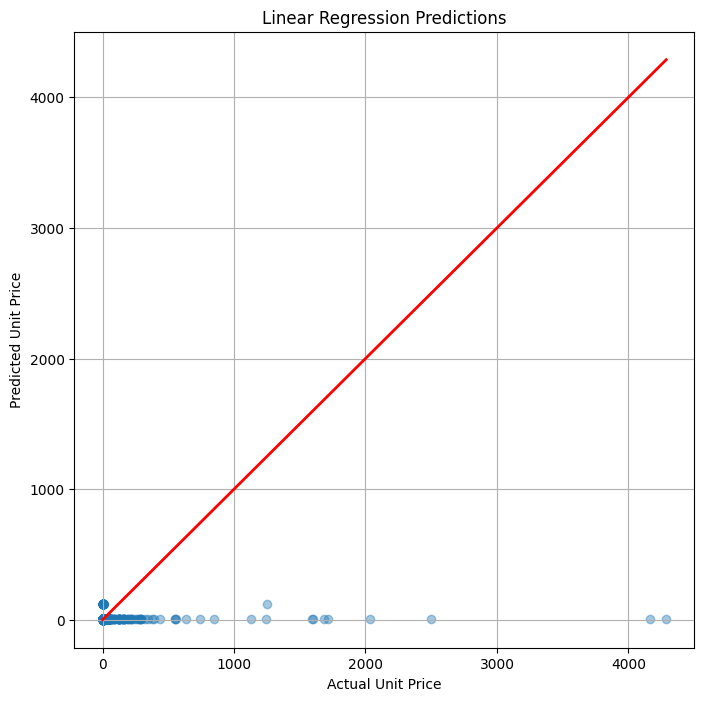

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Unit Price")
plt.ylabel("Predicted Unit Price")
plt.title("Linear Regression Predictions")
plt.grid(True)

plt.show()

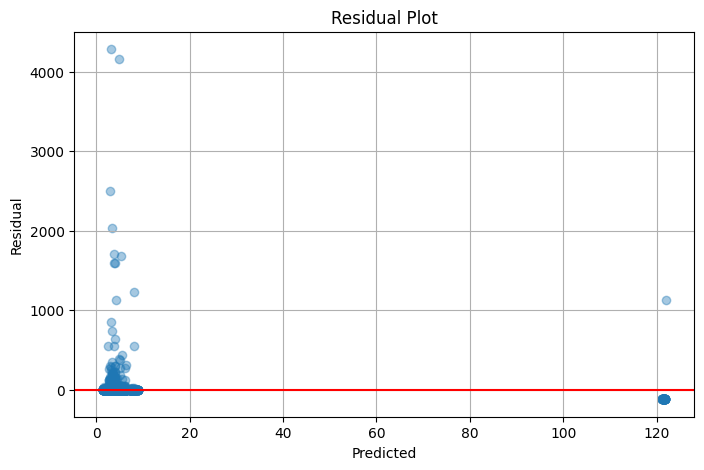

In [65]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.4)

plt.axhline(0, color="red")

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid(True)

plt.show()

In [66]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,1.65,3.830927
1,4.95,4.210110
2,0.85,3.099395
3,0.19,3.805819
4,0.42,3.182677
5,0.42,3.180863
6,2.08,2.886521
7,0.85,3.615368
8,2.08,4.291359
9,3.75,5.234744
